# 张量网络（numpy）

In [6]:
import quante as qt
import quante.tensornetwork as tn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
op = qt.generate.operas

## 第一部分 MPS

In [4]:
L = 10
𝜓 = tn.MPS.from_random(L, bond_dim=4, dtype=np.float64)
𝜓.move_llim_(3)
𝜓.move_rlim_(6)
𝜓.show()

MPS;  float64;  norm: 1.637e+04;  maxbonddim: 4;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
         ----|>----|>----|>----O-----O-----O-----O----<|----<|----<|-----
bonddim:  1     2     4     4     4     4     4     4     4     2     1  
site:        0     1     2     3     4     5     6     7     8     9     



建立一些常用的 mps

In [3]:
tn.MPS.from_ghz_state(L=3)  # |000> + |111>
tn.MPS.from_w_state(L=3, which='up')  # |001> + |010> + |100>
tn.MPS.from_w_state(L=3, which='down')  # |110> + |101> + |011>
tn.MPS.from_vector(np.random.randn(2**4) + 1j*np.random.randn(2**4)) 
tn.MPS.from_product_state(['up', 'down']*5)  # |1010101010>

MPS;  float64;  norm: 1.000e+00;  maxbonddim: 1;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
         ----O-----O-----O-----O-----O-----O-----O-----O-----O-----O-----
bonddim:  1     1     1     1     1     1     1     1     1     1     1  
site:        0     1     2     3     4     5     6     7     8     9     

移动正交中心

In [4]:
𝜓.orthogonalize_(0)
𝜓

MPS;  float64;  norm: 4.329e+03;  maxbonddim: 4;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
         ----O----<|----<|----<|----<|----<|----<|----<|----<|----<|-----
bonddim:  1     2     4     4     4     4     4     4     4     2     1  
site:        0     1     2     3     4     5     6     7     8     9     

计算 norm，归一化

In [5]:
𝜓.norm()

4328.835069221944

In [6]:
(𝜓 | 𝜓)**0.5

4328.835069221944

In [7]:
𝜓.normalize_()
𝜓.norm()

1.0

计算纠缠熵

In [8]:
𝜓.entanglement_entropy(range(1,L))

[0.2761709729606717,
 0.6468335872366086,
 0.581190425469323,
 0.7128552758418687,
 0.6112551314348164,
 0.4278961165554929,
 0.29659399997248287,
 0.3902503872035191,
 0.4342902372397599]

计算局域观测量

In [9]:
𝜓.measure('x',[0])
𝜓.measure('xx',[0, 2])
𝜓.measure(np.random.randn(4,4), [0, 1])
𝜓.measure(op.heisenberg_operator(L-1))
mpo = tn.MPO.from_random(L=2, bond_dim=2, dtype=np.float64)
print(𝜓.measure(mpo, 1))
print(𝜓.measure(mpo.to_matrix(), [1,2]))

-0.15424659993442427
-0.15424659993442427


In [10]:
(𝜓 | ('x', [0]) | 𝜓)
(𝜓 | ('xx', [0,2]) | 𝜓)
(𝜓 | (np.random.randn(4,4), [0,1]) | 𝜓)
(𝜓 | op.heisenberg_operator(L-1) | 𝜓)

-0.3305581599190221

In [11]:
tmp = tn.MPS.from_product_state(['up', 'down']*10)  # |1010101010>
[tmp.measure('Z',[i]).item() for i in range(9)]

[1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0]

计算矩阵元

In [12]:
𝜓1 = tn.MPS.from_random(L, bond_dim=4, dtype=np.float64)
𝜓2 = tn.MPS.from_random(L, bond_dim=4, dtype=np.float64)

print(𝜓1 | ('x', [0]) | 𝜓2)
𝜓2.apply_gate_(0, qt.generate.matrix.pauli_matrix('x'), gate_range=1)
print(𝜓1 | 𝜓2)

print(𝜓1 | ('xx', [L-2,L-1]) | 𝜓2)
𝜓2.apply_gate_(L-2, qt.generate.matrix.pauli_matrix('xx'), gate_range=2)
print(𝜓1 | 𝜓2)

mat = np.random.randn(4,4)
print(𝜓1 | (mat, [0,1]) | 𝜓2)
𝜓2.apply_gate_(0, mat, gate_range=2)
print(𝜓1 | 𝜓2)

print(𝜓1 | op.heisenberg_operator(L-1) | 𝜓2)
print(𝜓1 | op.heisenberg_operator(L-1).to_mpo(L=10) | 𝜓2)

-401228.7544849549
-401228.7544849549
-152629.99984841107
-152629.999848411
692.7700903547229
692.7700903546065
816809.0042367211
816809.0042367211


作用局域门

In [13]:
mat = np.random.randn(4,4)
n𝜓 = 𝜓.copy()  # 复制原来的 𝜓
n𝜓.apply_gate_(0, mat)  # 在 (0,1) 位置作用一个 4x4 的矩阵

TruncationError(eps=0.0, ov=1.0)

内积

In [14]:
print(𝜓 | n𝜓)
print(𝜓.inner(n𝜓))  # < ψ | nψ >
𝜓.measure(mat, [0,1])  # 与内积结果相同

-0.12252731563703359
-0.12252731563703359


-0.12252731563703381

tebd

100%|##########| 100/100 [00:00<00:00, 260.77it/s]


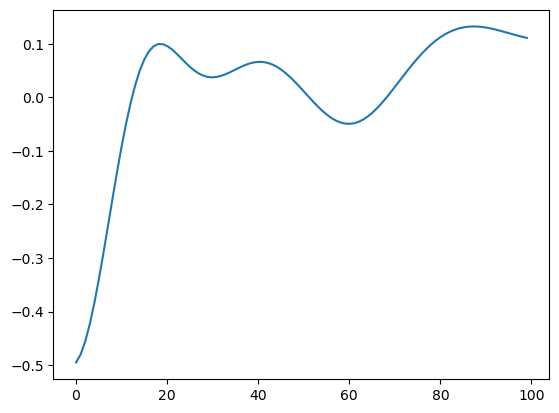

In [ ]:
ham = op.heisenberg_operator(L)
𝜓t = tn.MPS.from_product_state(["up", "down"]*(L//2), dtype=np.complex128)
gates = ham.trotter_gates(L, tau=0.1, pauli=False)
res = []
for i in tqdm(range(100), ascii=True):
    for pos, gate in zip(*gates):
        𝜓t.apply_gate_(pos, gate)
    res.append(𝜓t.measure('z', [3]).item().real)
plt.plot(res)

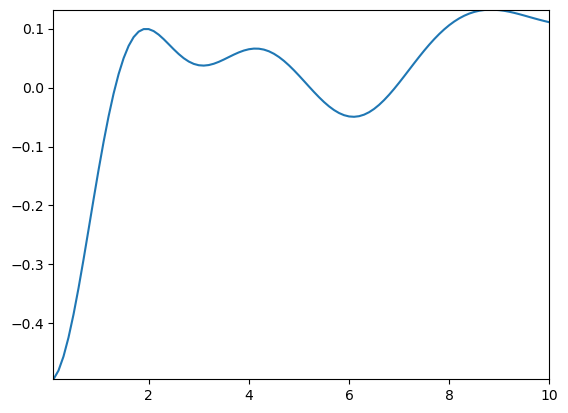

In [10]:
# 封装好的版本
ham = op.heisenberg_operator(L)
psi0 = tn.MPS.from_product_state(["up", "down"] * (L // 2), dtype=np.complex128)

eng = tn.TEBDEvolveEngine(ham, psi0, tau=0.1, steps=100, pauli=False)
res = eng.plot(measure="z", pos=[3])

# plt.plot(res.reshape(-1))

## itebd

100%|##########| 200/200 [00:05<00:00, 34.60it/s]


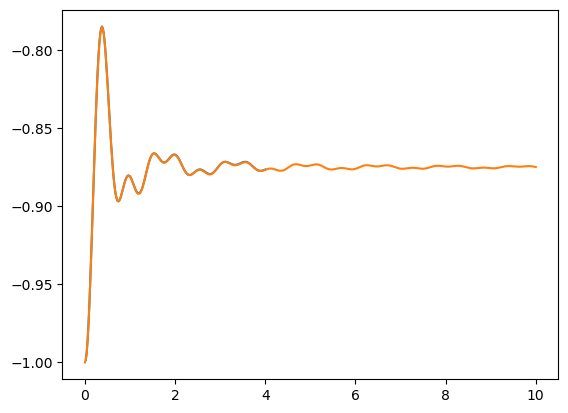

In [16]:
# 生成无穷长 MPS
tmp1 = np.zeros((1,2,1), dtype=np.complex128)
tmp1[0,1,0] = 1.
tmp2 = np.zeros((1,2,1), dtype=np.complex128)
tmp2[0,1,0] = 1.

psi = tn.MPS([tmp1, tmp2], [np.array(1.), np.array(1.)], L=np.inf)

# 生成两体门
g = 2
ham = op.xx(0,1) + 0.5 * g * op.z(0) + 0.5 * g * op.z(1)
basis = qt.generate.basis.spin_basis(2)
mat = ham.to_matrix(basis, pauli=True)
t = 0.02  # 0.05 会有明显误差
expiH = qt.linalg.expm(mat, -1j*t).reshape(2,2,2,2)

# itebd 演化
ts = []
sz = []
bonds = []
cur_t = 0.
for i in tqdm(range(200), ascii=True):
    psi.apply_gate_(0, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    psi.apply_gate_(1, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    cur_t += t
    sz.append(psi.measure('Z', 0).real)
    ts.append(cur_t)
    bonds.append(psi.maxbonddim())
import matplotlib.pyplot as plt
plt.plot(ts, sz)

#############################
# 对比严格解
#############################
import scipy.integrate as spi
jx = 1
jy = 0
hz = 2
λ = (jx + jy)/2
γ = (jx - jy)/2
theta = lambda k: np.arctan2(2*γ*np.sin(k),  hz - 2*λ*np.cos(k))
omega = lambda k: 2 * np.sqrt((2*γ*np.sin(k))**2 + (hz - 2*λ*np.cos(k))**2)
ts = np.linspace(0, 10, 500)
sigma_zs = np.zeros_like(ts, dtype=np.float64)
for i, t in enumerate(ts):
    sigma_zs[i] = 1/np.pi * spi.quad(lambda k: np.sin(theta(k))**2 * np.sin(omega(k) * t)**2, -np.pi, np.pi)[0] - 1
plt.plot(ts, sigma_zs)


## 第二部分 MPO

使用 automata 建立一个 mpo

In [17]:
ham = op.heisenberg_operator(L)

In [18]:
ℋ = ham.to_mpo(pauli=False)
eng, vec1 = ℋ.dmrg()
ℋ

Sweep 3: 100%|##########| 18/18 [00:00<00:00, 193.56it/s, pE=-4.2580e+00, chi=20]

Energy converged to -4.2580352068 after 3 sweeps.


MPO;  float64;  norm: 4.157e+01;  maxbonddim: 5;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
         ----O-----O-----O-----O-----O-----O-----O-----O-----O-----O-----
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
bonddim:  1     4     5     5     5     5     5     5     5     5     1  
site:        0     1     2     3     4     5     6     7     8     9     

也可以使用 quimb 建立 mpo

In [19]:
# ham = op.heisenberg_operator(L)
# quimbH = ham.to_mpo(pauli=False).to_quimb
# quimbH.draw()

计算内积

In [19]:
L = 100
ham = op.heisenberg_operator(L) + op.y(0)
H = ham.to_mpo(pauli=False)
psi = tn.MPS.from_random(L, bond_dim=4)

print(H.mele(psi, psi))  # <psi|H|psi>
print(psi | H | psi)

(-2.851542422312216e+117+1.1898643942819585e+102j)
(-2.851542422312216e+117+1.1898643942819585e+102j)


## dmrg

dmrg 算基态

In [20]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False)
eng, vec = H.dmrg(nsweep=10)

print("eng:  ", eng)
print("inner:", (vec | H | vec))
print("exact:", ham.gdenergy(pauli=False))

Sweep 4: 100%|##########| 18/18 [00:00<00:00, 186.56it/s, pE=-4.2580e+00, chi=20]


Energy converged to -4.2580352068 after 4 sweeps.
eng:   -4.258035206805349
inner: -4.258035206805347
exact: -4.25803520728288


In [21]:
L = 100
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False)

eng, vec = H.dmrg(nsweep=10)

Sweep 5: 100%|##########| 198/198 [00:03<00:00, 62.17it/s, pE=-4.4128e+01, chi=108]

Energy converged to -44.1277398593 after 5 sweeps.


dmrg 算第一激发态

In [22]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False)
eng, vec1 = ℋ.dmrg()
eng, vec2 = ℋ.dmrg(Ms=[vec1])
ham.gdenergy(pauli=False, k=2) # ed 结果

Sweep 4: 100%|##########| 18/18 [00:00<00:00, 189.47it/s, pE=-4.2580e+00, chi=20]


Energy converged to -4.2580352068 after 4 sweeps.


Sweep 4: 100%|##########| 18/18 [00:00<00:00, 181.82it/s, pE=-3.9307e+00, chi=20]

Energy converged to -3.9306735894 after 4 sweeps.


array([-3.93067359, -4.25803521])

In [23]:
L = 100
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False)
eng, vec1 = ℋ.dmrg()
eng, vec2 = ℋ.dmrg(Ms=[vec1])

Sweep 5: 100%|##########| 198/198 [00:03<00:00, 63.08it/s, pE=-4.4128e+01, chi=108]


Energy converged to -44.1277398595 after 5 sweeps.


Sweep 5: 100%|##########| 198/198 [00:03<00:00, 57.86it/s, pE=-4.4087e+01, chi=105]

Energy converged to -44.0872991514 after 5 sweeps.


dmrg 算 MPO 求和的基态

In [24]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False)
hams = [ham + op.sum(np.random.rand() * op.z(i) for i in range(L)) for _ in range(10)]
mpos = [h.to_mpo() for h in hams]
tn.DMRG(mpos).run2()

op.sum(hams).gdenergy(pauli=False) # ed 的结果

Sweep 4: 100%|##########| 18/18 [00:00<00:00, 215.65it/s, pE=-4.4082e+01, chi=16]


Energy converged to -44.0817061182 after 4 sweeps.


-44.08170611964919

准一维系统的基态
```
      0   2   4   6
   ---◻---◻---◻---◻---
      |   |   |   |
   ---◻---◻---◻---◻---
      1   3   5   7
```

In [25]:
j1, j2, j3 = 1.0, 2.0, 1.0

for L in range(4, 10):
    
    builder = op.builder()

    for i in range(L-1):
        # S
        builder += 'xx', [2*i, 2*i+2], j1
        builder += 'yy', [2*i, 2*i+2], j1
        builder += 'zz', [2*i, 2*i+2], j1
        # L
        builder += 'xx', [2*i+1, 2*i+3], j2
        builder += 'yy', [2*i+1, 2*i+3], j2
        builder += 'zz', [2*i+1, 2*i+3], j1

    for i in range(L):
        # SL
        builder += 'xx', [2*i, 2*i+1], j3
        builder += 'yy', [2*i, 2*i+1], j3
        builder += 'zz', [2*i, 2*i+1], j3

    H = builder.build()

    Hmpo = H.to_mpo(L=2*L, pauli=False)
    E, _ = Hmpo.dmrg(outputlevel=0)

    print(f"L={L}, E={E.item()}")

L=4, E=-5.149175306097188
L=5, E=-6.5495393167336005
L=6, E=-7.967781414086798
L=7, E=-9.379011865164117
L=8, E=-10.793329593796734
L=9, E=-12.206480860262154


## tdvp

 50%|#####     | 50/100 [00:08<00:08,  5.98it/s]


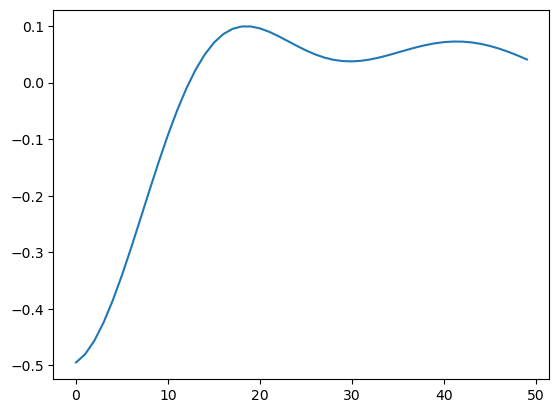

In [26]:
L = 12
H = op.heisenberg_operator(L).to_mpo(pauli=False)
𝜓t = tn.MPS.from_product_state(["up","down"]*(L//2))
psis = H.tdvp(init=𝜓t, time_step=-0.1j, final_time=-5.j, outputlevel=0)
Ss = []
for t, phi in tqdm(psis, ascii=True, total=100):
    Ss.append(phi.measure('z', 3).item().real)
import matplotlib.pyplot as plt
plt.plot(Ss)

In [1]:
import quante as qt
import quante.tensornetwork as tn
op = qt.generate.operas

L = 10
psi = tn.MPS.from_product_state(['up', 'down']*5)
psi

MPS;  float64;  norm: 1.000e+00;  maxbonddim: 1;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
         ----O-----O-----O-----O-----O-----O-----O-----O-----O-----O-----
bonddim:  1     1     1     1     1     1     1     1     1     1     1  
site:        0     1     2     3     4     5     6     7     8     9     

In [4]:
L = 10
psi = tn.MPS.from_random(L=L, bond_dim=4)
psi.normalize_()
psi.orthogonalize_(5)
psi

MPS;  complex128;  norm: 1.000e+00;  maxbonddim: 4;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|               
         ----|>----|>----|>----|>----|>----O----<|----<|----<|----<|-----
bonddim:  1     2     4     4     4     4     4     4     4     2     1  
site:        0     1     2     3     4     5     6     7     8     9     

In [5]:
(psi|('x', 0)|psi)

(0.14615563037117618+0j)

In [6]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False)
eng, vec = H.dmrg(nsweep=10)
print(vec | H | vec)
ham.gdenergy(pauli=False)

Sweep 3: 100%|##########| 18/18 [00:00<00:00, 194.56it/s, pE=-4.2580e+00, chi=20]


Energy converged to -4.2580352068 after 3 sweeps.
-4.258035206805349


-4.25803520728288